In [42]:
# ----------------------------------------
# 📦 1. Import Required Libraries
# ----------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# ----------------------------------------
# 📥 2. Load Datasets
# ----------------------------------------
train_df = pd.read_csv("titanic/train.csv")
test_df = pd.read_csv("titanic/test.csv")
original_test_df = test_df.copy() # Save PassengerId for final submission

# ----------------------------------------
# 🔎 3. Visualize Raw Data
# ----------------------------------------
# summary of dataset
train_df.info()
# check for missing values
train_df.isnull().sum()
# descriptive statistics
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


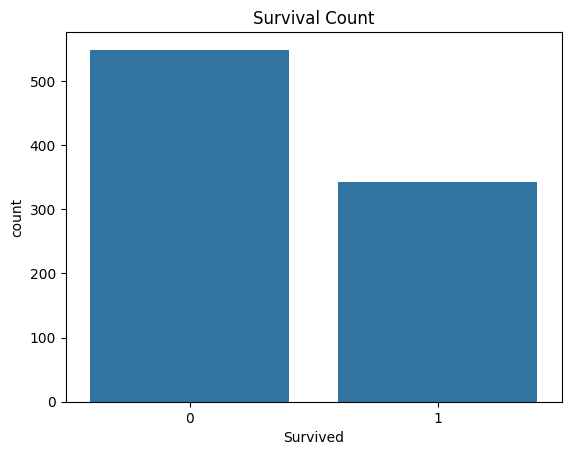

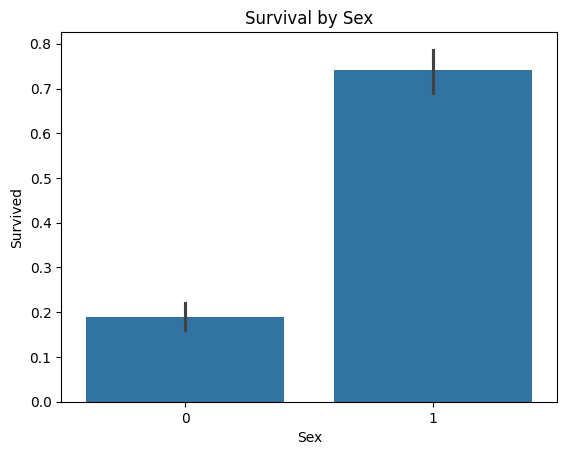

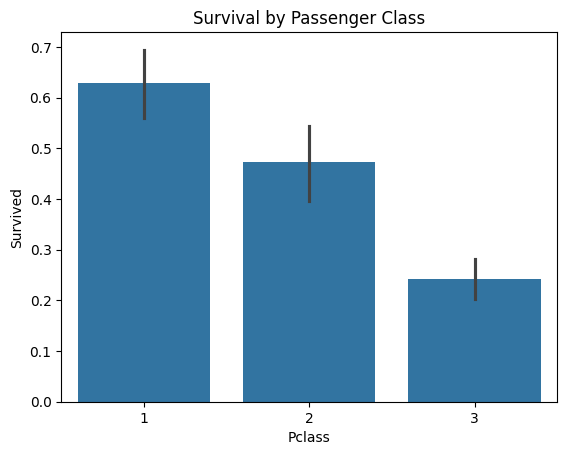

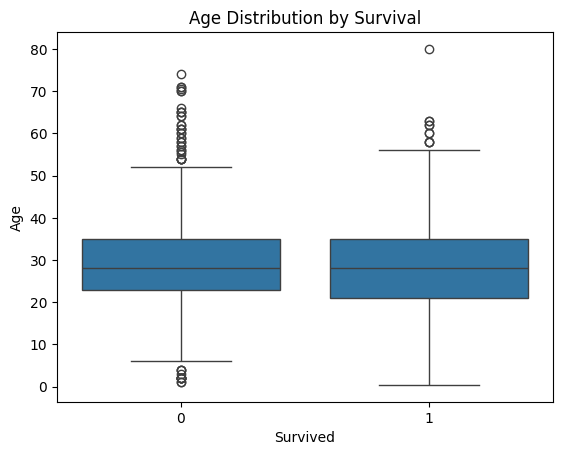

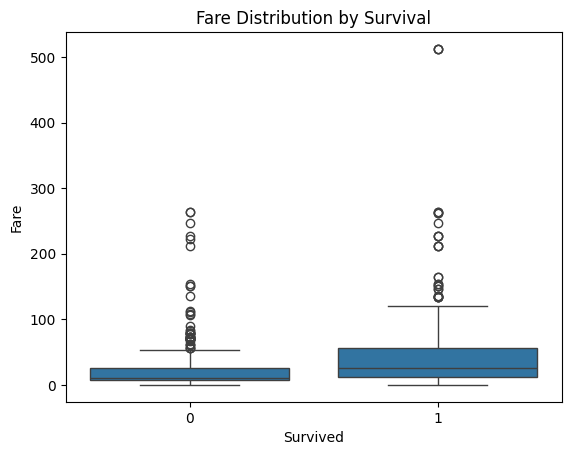

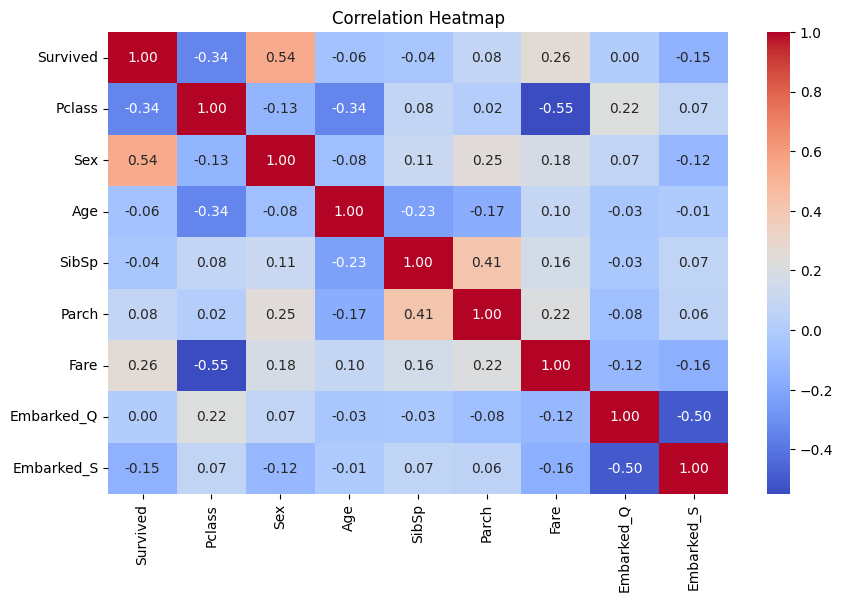

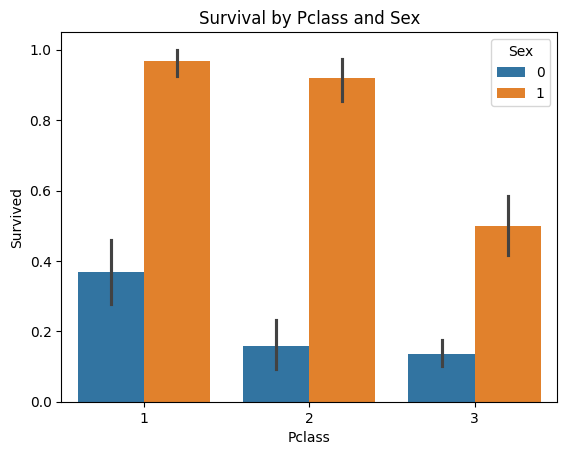

In [43]:
# ----------------------------------------
# 🧼 4. Clean & Encode Data (Train)
# ----------------------------------------
train_df = train_df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df = pd.get_dummies(train_df, columns=['Embarked'], drop_first=True) # One-Hot Encoding

# ----------------------------------------
# 🧼 5. Clean & Encode Data (Test)
# ----------------------------------------
test_df = test_df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True) # One-Hot Encoding

# ----------------------------------------
# 📊 6. Exploratory Data Analysis (EDA)
# ----------------------------------------
# Distributions & Class Imbalance [Countplot]
sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count")
plt.show()

# Categorical vs. Target [Bar Plot]
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title("Survival by Sex")
plt.show()

sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title("Survival by Passenger Class")
plt.show()

# Continuous vs. Target [Box Plot]
sns.boxplot(x='Survived', y='Age', data=train_df)
plt.title("Age Distribution by Survival")
plt.show()

sns.boxplot(x='Survived', y='Fare', data=train_df)
plt.title("Fare Distribution by Survival")
plt.show()

# Numeric Relationships in Features [Correlation Heatmap]
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Combined Category Plot
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_df)
plt.title("Survival by Pclass and Sex")

# ----------------------------------------
# 🏗️ 7. Feature Engineering
# ----------------------------------------
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df = train_df.drop(columns=['SibSp', 'Parch'])

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df = test_df.drop(columns=['SibSp', 'Parch'])

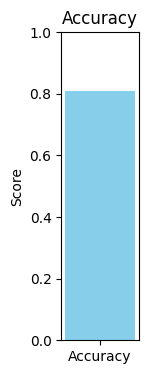

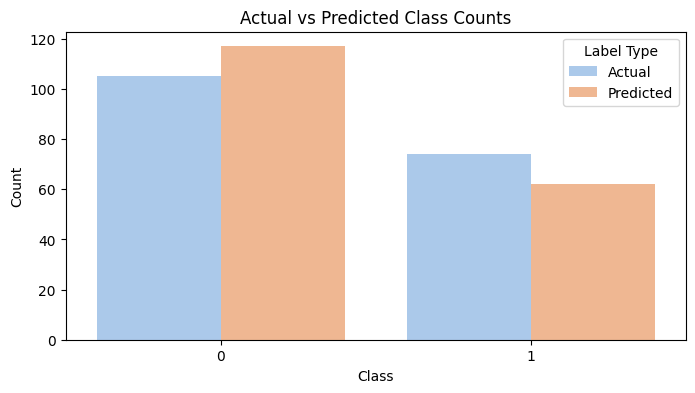

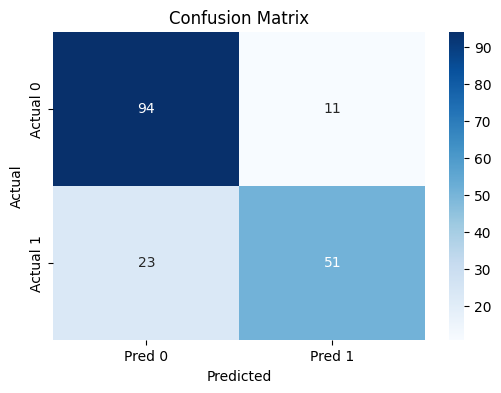

              precision    recall  f1-score   support

        Died       0.86      0.87      0.86       105
    Survived       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



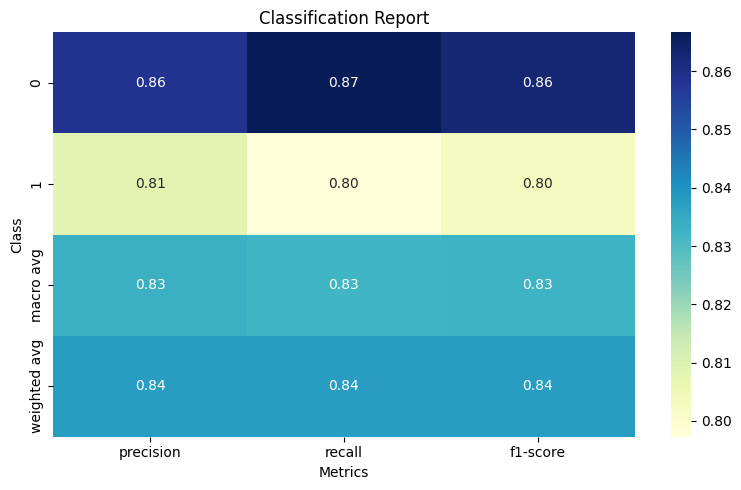

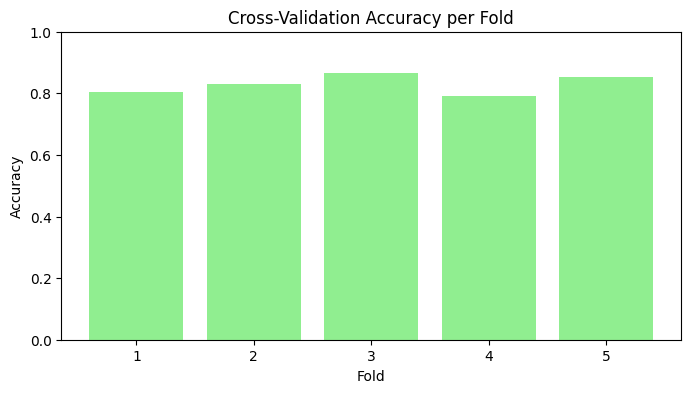

Mean CV Accuracy: 0.8294
Standard Deviation: 0.0279


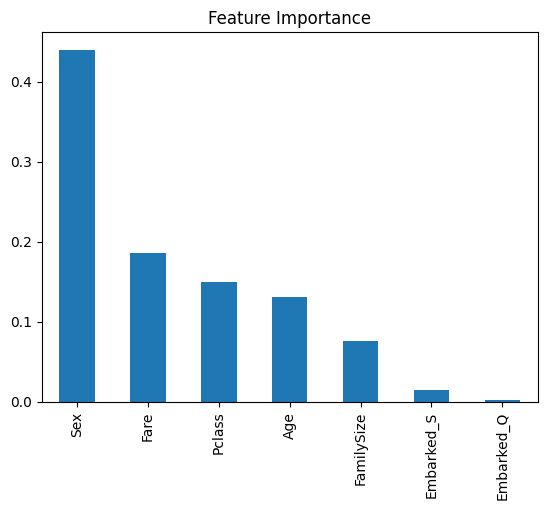

In [44]:
# ----------------------------------------
# 🤖 8. Model Training and Validation
# ----------------------------------------
# Split Data
X = train_df.drop(columns=['Survived'])
y = train_df['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=4,
    n_estimators=300,
    subsample=0.8
)
model.fit(X_train, y_train)

# Predict - Validation Set
val_predictions = model.predict(X_val)
accuracy = accuracy_score(y_val, val_predictions)

# ----------------------------------------
# 📈 9. Model Evaluation
# ----------------------------------------
# 1. Accuracy - Bar Plot
plt.figure(figsize=(1, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': val_predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_val, val_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
probs = model.predict_proba(X_val)[:, 1] # Get the predicted probabilities
val_predictions_thresh = (probs >= 0.4).astype(int) # Change threshold (default is 0.5)
print(classification_report(y_val, val_predictions_thresh, target_names=['Died', 'Survived']))

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=5)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.show()

# Mean and standard deviation
mean_score = scores.mean()
std_score = scores.std()

print(f"Mean CV Accuracy: {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")

# ----------------------------------------
# 📤 10. Create Submission File
# ----------------------------------------
test_predictions = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': original_test_df['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv("submission.csv", index=False)

In [ ]:
# ----------------------------------------
#  11. Other
# ----------------------------------------
# Feature Importance
importances = model.feature_importances_
features = X.columns
pd.Series(importances, index=features).sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()